## CHAOS record figures

Snapshot, marginal spectra, and timeline for the selected CHAOS SV record.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *

plt.rcParams.update({"font.size": 11})

['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']


In [7]:
# Select a snapshot by its index in times_chosen
demo_time = 30

nmax = 15
times_chosen = times_used
gnm_chaos = CHAOS_Full_SV_Record_Obtain(nmax=nmax)

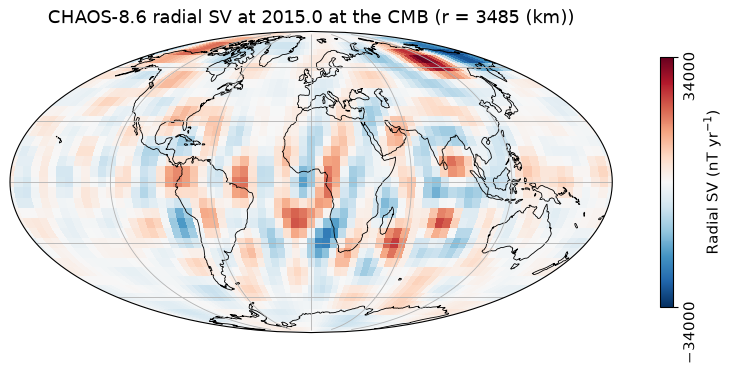

In [8]:
import cartopy.crs as ccrs

# Radial SV snapshot at the core-mantle boundary
sv_snapshot = (A_15_r @ gnm_chaos[demo_time]).reshape(state_shape)
plot_longitude = (longitude + 180) % 360 - 180
longitude_order = np.argsort(plot_longitude)
colour_limit = np.ceil(np.max(np.abs(sv_snapshot)) / 1000) * 1000

fig, ax = plt.subplots(
    figsize=(text_width, 0.7 * text_width),
    subplot_kw={"projection": ccrs.Mollweide()},
    constrained_layout=True,
)

map_plot = ax.pcolormesh(
    plot_longitude[longitude_order],
    latitude,
    sv_snapshot[:, longitude_order],
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-colour_limit,
    vmax=colour_limit,
    shading="auto",
)

ax.coastlines(color="black", linewidth=0.6)
ax.set_global()
ax.set_title(f"CHAOS-8.6 radial SV at {times_chosen[demo_time]:.1f} at the CMB (r = {r_cmb} (km))")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.gridlines(color="0.7", linewidth=0.6)

cbar = fig.colorbar(
    map_plot,
    ax=ax,
    pad=0.08,
    shrink=0.5,
    label=r"Radial SV (nT yr$^{-1}$)",
)
cbar.set_ticks([-colour_limit, colour_limit])
cbar.ax.tick_params(labelrotation=90)

plt.savefig(f"{RESULT_DIR}/1_chaos_sv.pdf", bbox_inches="tight")
plt.show()

plt.show()

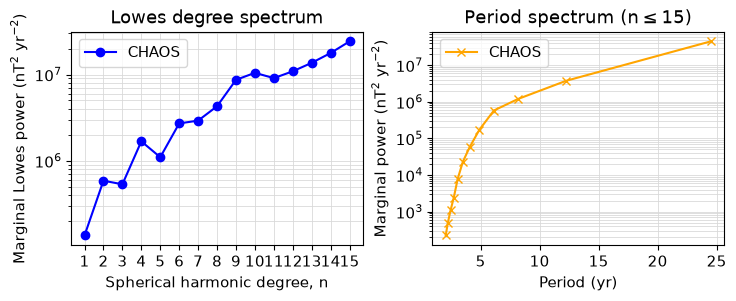

In [5]:
# Marginal Lowes degree and frequency spectra of the chosen record
chaos_power, chaos_f = Lowes_Degree_PSD_All_Degrees(
    gnm_chaos, a=r_earth, r=r_cmb, f_sample=f_sample, nmax=nmax
)

chaos_n = np.arange(1, nmax + 1)
non_zero_f = chaos_f > 0
marginal_n = np.sum(chaos_power, axis=1)
marginal_f = np.sum(chaos_power, axis=0)

fig, axes = plt.subplots(
    1, 2, figsize=(text_width, 0.4 * text_width), constrained_layout=True
)
axes[0].semilogy(chaos_n, marginal_n, color="blue", label="CHAOS", marker='o')
axes[0].set(
    xlabel="Spherical harmonic degree, n",
    ylabel=r"Marginal Lowes power (nT$^2$ yr$^{-2}$)",
    title="Lowes degree spectrum",
)
axes[0].set_xticks(chaos_n)

axes[1].semilogy(
    1/chaos_f[non_zero_f], marginal_f[non_zero_f], color="orange", label="CHAOS", marker='x'
)
axes[1].set(
    xlabel=r"Period (yr)",
    ylabel=r"Marginal power (nT$^2$ yr$^{-2}$)",
    title="Period spectrum (n$\leq 15$)",
)

for ax in axes:
    ax.grid(True, which="both", color="0.85", linewidth=0.6)
    ax.legend()

plt.savefig(f"{RESULT_DIR}/1_chaos_power_spectra.pdf", bbox_inches="tight")

plt.show()

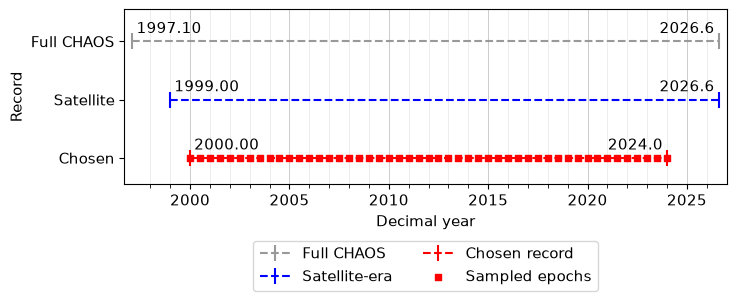

In [6]:
# Timeline of the full, reliable, and chosen CHAOS records
chaos_start, chaos_end = 1997.1, 2026.6
satellite_data_start = 1999
chosen_start, chosen_end = times_chosen[[0, -1]]

fig, ax = plt.subplots(
    figsize=(text_width, 0.4 * text_width), constrained_layout=True
)
records = [
    (2, chaos_start, chaos_end, "0.6", "Full CHAOS"),
    (1, satellite_data_start, chaos_end, "blue", "Satellite-era"),
    (0, chosen_start, chosen_end, "red", "Chosen record"),
]

for y, start, end, colour, label in records:
    ax.plot(
        [start, end], [y, y], "--", color=colour, linewidth=1.5,
        marker="|", markersize=12, markeredgewidth=1.5, label=label,
    )
    ax.annotate(f"{start:.2f}", (start, y), xytext=(3, 6), textcoords="offset points")
    ax.annotate(
        f"{end:.1f}", (end, y), xytext=(-3, 6),
        textcoords="offset points", ha="right",
    )

ax.scatter(
    times_chosen, np.zeros_like(times_chosen), s=15, marker="s",
    color="red", zorder=3, label="Sampled epochs",
)
ax.set(
    xlim=(chaos_start - 0.4, chaos_end + 0.4),
    ylim=(-0.45, 2.55),
    xlabel="Decimal year",
    ylabel="Record",
    yticks=[0, 1, 2],
    yticklabels=["Chosen", "Satellite", "Full CHAOS"],
)
ax.set_xticks(np.arange(np.ceil(chaos_start), np.floor(chaos_end) + 1), minor=True)
ax.set_xticks(np.arange(2000, 2026, 5))
ax.tick_params(axis="x", which="minor", length=3, color="black")
ax.grid(True, axis="x", which="major", color="0.8", linewidth=0.7)
ax.grid(True, axis="x", which="minor", color="0.9", linewidth=0.5)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=2)


plt.savefig(f"{RESULT_DIR}/1_chaos_timeline.pdf", bbox_inches="tight")


plt.show()